In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv('UCI_Credit_Card.csv')
df.head(2)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [3]:
df.isnull().sum()  #No missing observations

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [ ]:
df.drop('ID',axis=1,inplace=True) #Removing unimportant feature
df.head(2)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1


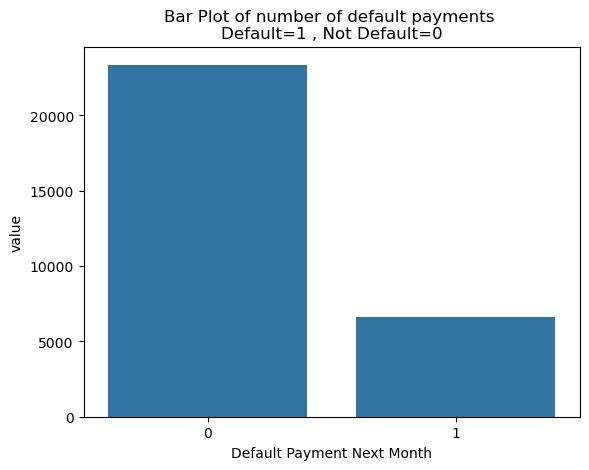

In [22]:
temp=df['default.payment.next.month'].value_counts()
df_1=pd.DataFrame({'default.payment.next.month':temp.index,'value':temp.values})
plt.Figure(figsize=(6,4))
sns.set_color_codes(palette='deep')
sns.barplot(data=df_1,x='default.payment.next.month',y='value')
plt.title("Bar Plot of number of default payments \nDefault=1 , Not Default=0")
plt.xlabel("Default Payment Next Month")
plt.show()

<Axes: title={'center': 'Histogram of Credit Limit'}, xlabel='Limit Balance', ylabel='Count'>

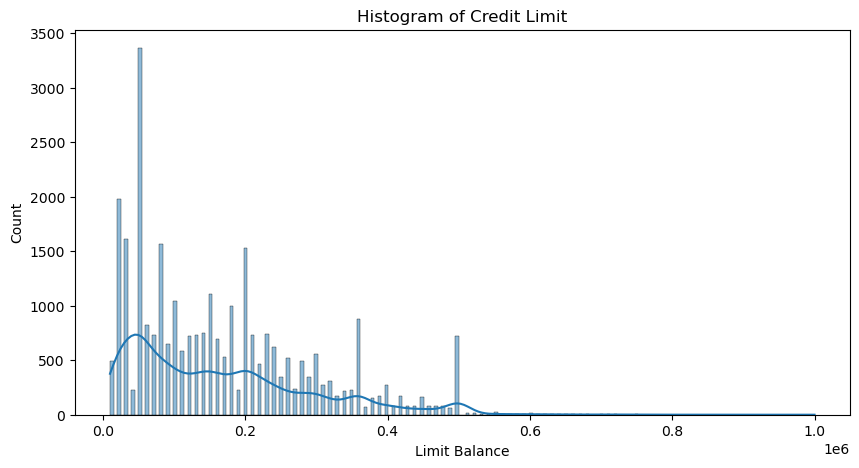

In [28]:
plt.figure(figsize=(10,5))
plt.title("Histogram of Credit Limit")
plt.xlabel('Limit Balance')
sns.histplot(df['LIMIT_BAL'],kde=True,bins=200,)


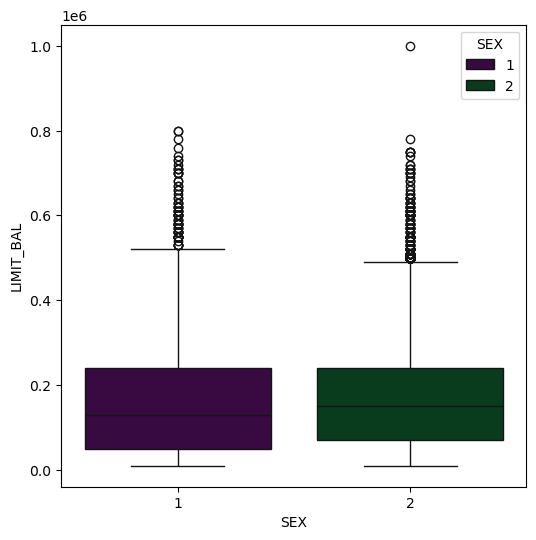

In [29]:
plt.figure(figsize=(6,6))
s = sns.boxplot(x="SEX", y="LIMIT_BAL", hue="SEX",data=df, palette="PRGn",showfliers=True)
plt.show()

<Axes: title={'center': 'Amount of bill statement (Apr-Sept) \ncorrelation plot (Pearson)'}>

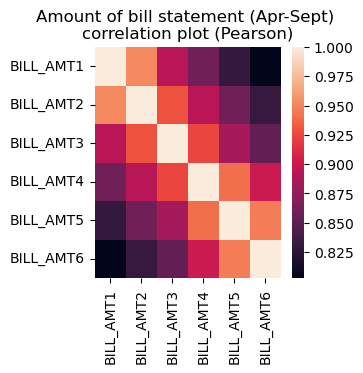

In [43]:
var = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
plt.figure(figsize=(3,3))
plt.title('Amount of bill statement (Apr-Sept) \ncorrelation plot (Pearson)')
sns.heatmap(df[var].corr())


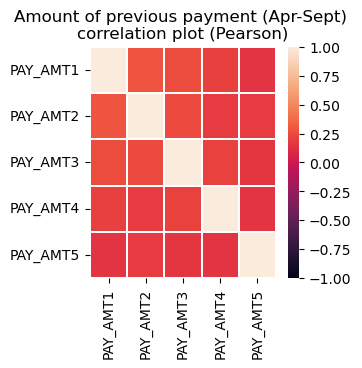

In [44]:
var = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']

plt.figure(figsize = (3,3))
plt.title('Amount of previous payment (Apr-Sept) \ncorrelation plot (Pearson)')
corr = df[var].corr()
sns.heatmap(corr,xticklabels=corr.columns,yticklabels=corr.columns,linewidths=.1,vmin=-1, vmax=1)
plt.show()

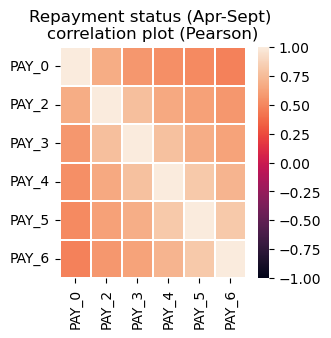

In [45]:
var = ['PAY_0','PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

plt.figure(figsize = (3,3))
plt.title('Repayment status (Apr-Sept) \ncorrelation plot (Pearson)')
corr = df[var].corr()
sns.heatmap(corr,xticklabels=corr.columns,yticklabels=corr.columns,linewidths=.1,vmin=-1, vmax=1)
plt.show()

In [50]:
def box_var(feature1, feature2, feature3, width=16):
    fig, ax1 = plt.subplots(ncols=1, figsize=(width,6))
    sns.boxplot(ax = ax1, x=feature1, y=feature2, hue=feature3,data=df, palette='pastel',showfliers=False)  
    plt.show()

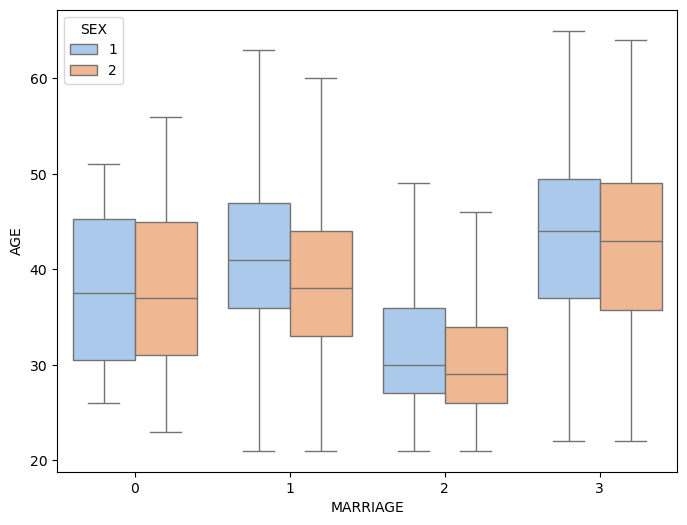

In [52]:
box_var('MARRIAGE','AGE','SEX',8)

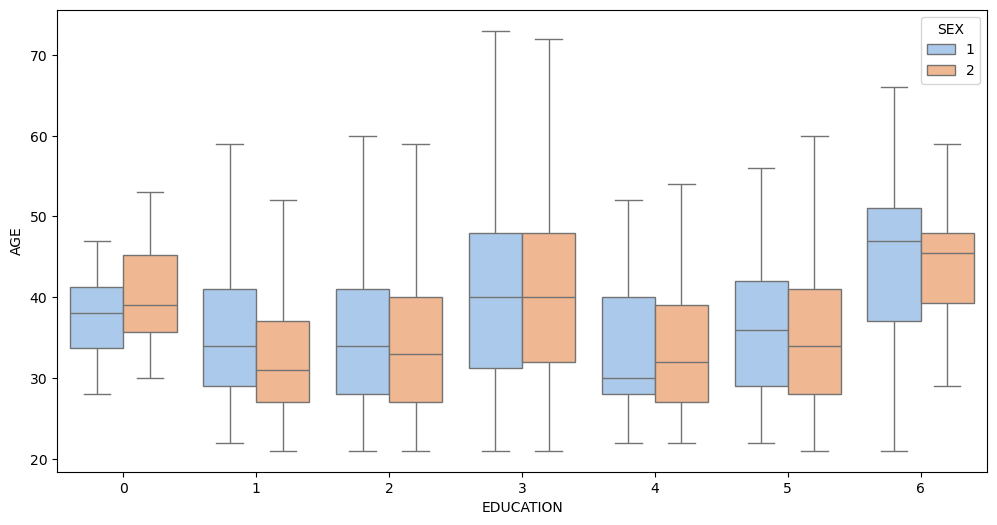

In [54]:
box_var('EDUCATION','AGE','SEX',12)

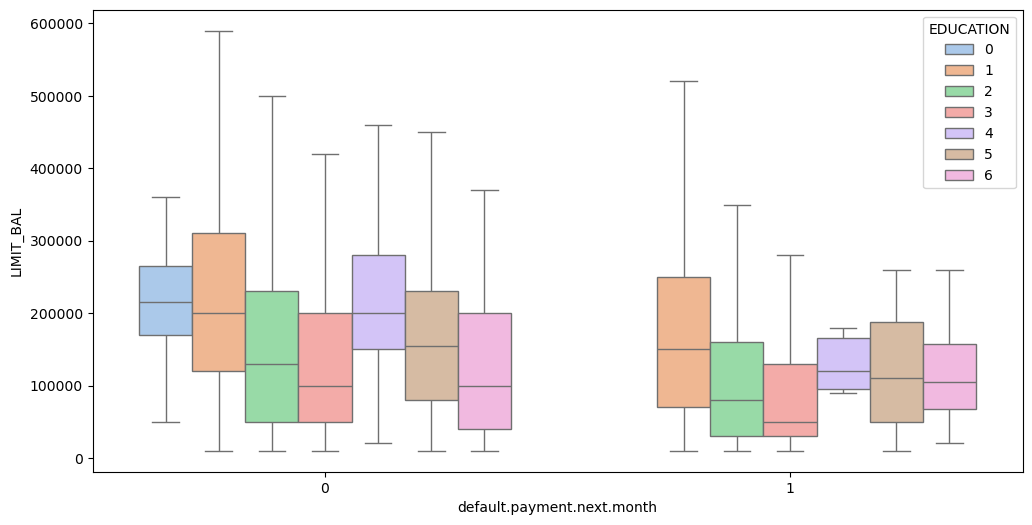

In [55]:
box_var('default.payment.next.month','LIMIT_BAL','EDUCATION',12)

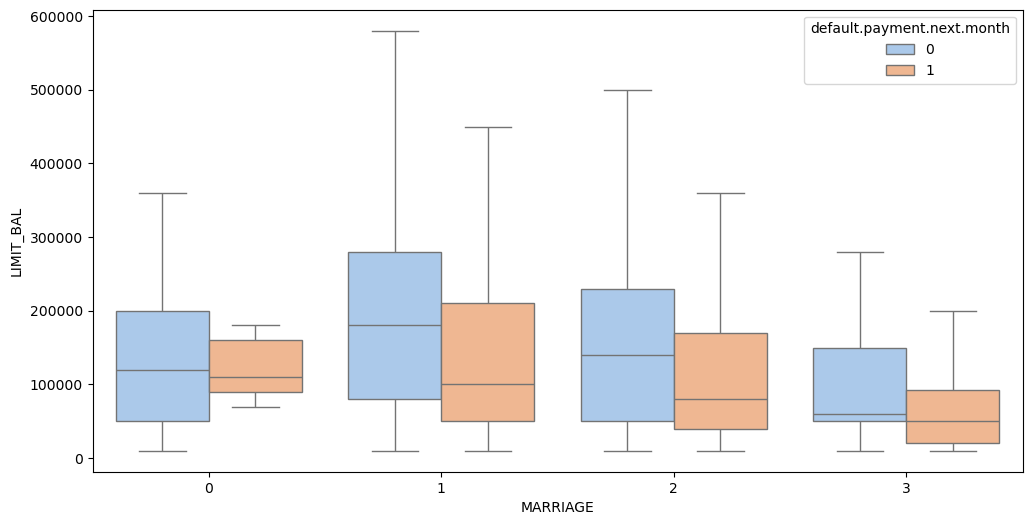

In [56]:
box_var('MARRIAGE','LIMIT_BAL', 'default.payment.next.month',12)